In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Membaca data
df = pd.read_csv("psd_polutan_lamongan_download.csv")

# Menghapus spasi pada nama kolom
df.columns = df.columns.str.strip()

# Mengubah tanggal
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Mengubah data polutan menjadi numerik
polutan = ["o3", "co", "no2", "so2"]

for kolom in polutan:
    df[kolom] = pd.to_numeric(df[kolom], errors="coerce")

# Mengurutkan berdasarkan tanggal
df = df.sort_values("date").reset_index(drop=True)

print("Nama kolom:")
print(df.columns.tolist())

print("\n5 data pertama:")
print(df.head())

Nama kolom:
['date', 'o3', 'co', 'no2', 'so2']

5 data pertama:
        date        o3        co       no2       so2
0 2025-08-12       NaN       NaN  0.000021       NaN
1 2025-08-24  0.117016       NaN       NaN  0.000547
2 2025-08-25  0.116607  0.024864       NaN  0.000447
3 2025-08-26  0.115195  0.030086  0.000029  0.000003
4 2025-08-27  0.116802  0.024034       NaN  0.000366


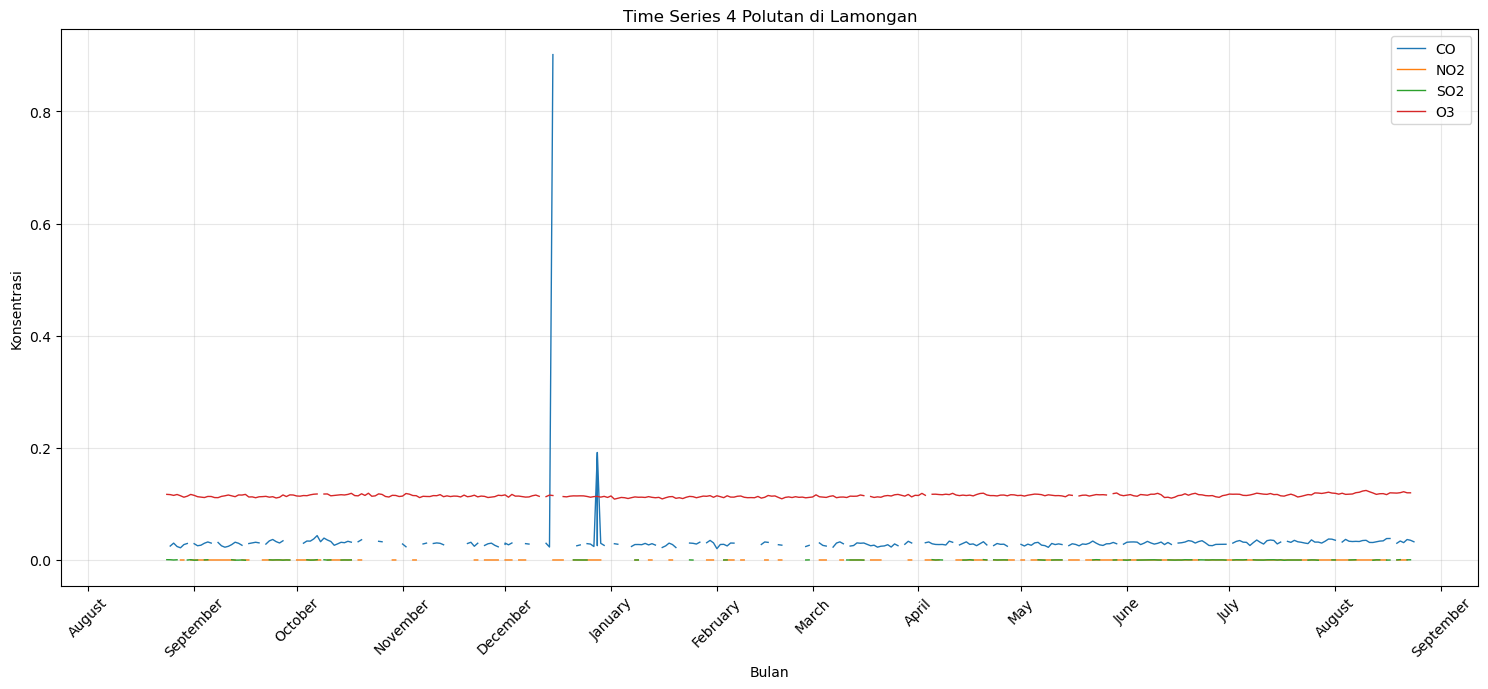

In [4]:
plt.figure(figsize=(15, 7))

plt.plot(df["date"], df["co"], label="CO", linewidth=1)
plt.plot(df["date"], df["no2"], label="NO2", linewidth=1)
plt.plot(df["date"], df["so2"], label="SO2", linewidth=1)
plt.plot(df["date"], df["o3"], label="O3", linewidth=1)

plt.title("Time Series 4 Polutan di Lamongan")
plt.xlabel("Bulan")
plt.ylabel("Konsentrasi")
plt.legend()

# Menampilkan nama bulan pada sumbu X
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%B"))

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()